In [4]:
# Linalg
import jax.numpy as np
import flax.linen as nn
import jax
import numpy as onp

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

# Helper libraries
from dataclasses import dataclass
import h5py as hf

/home/ac134186/miniconda3/envs/zincware/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/ac134186/miniconda3/envs/zincware/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
temperatures = [0, 150, 273, 300, 350]

In [5]:
@dataclass
class Measurement:
    data: np.ndarray
    uncertainty: np.ndarray

In [7]:
def transform_coordinates(position_data: np.ndarray, reference_data: np.ndarray):
    """
    Move colloids in all frames back into a single reference frame.
    Required for RDF calculation.
    
    Parameters
    ----------
    position_data : np.ndarray (time_steps, colloids, 3)
            Colloid data to transform.
    reference_data : np.ndarray (time_steps, colloids, 3)
            Rod data acting as reference.
    """
    # Convert to polar coordinates
    def inner_fn(
        position: np.ndarray, reference
    ):
        origin = np.array([500., 500., 0.])
        distance_vector = position - origin
        distance = np.linalg.norm(distance_vector)
        normed_distance = distance_vector / distance
        
        angle = np.arctan2(
            normed_distance[0] * reference[1] - normed_distance[1] * reference[0],
            normed_distance[0] * reference[0] + normed_distance[1] * reference[1]
        )
#         angle = np.arccos(references, normed_distance)
        return np.array([distance, angle])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, None))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    polar_coordinates = outer_map_fn(
        position_data, reference_data
    )
    
    # Convert to cartesian coordinates
    def inner_fn(
        distance: np.ndarray, angle: np.ndarray
    ):
        x = distance * np.cos(angle)
        y = distance * np.sin(angle)
        
        return np.array([x, y])
    
    mapped_fn = jax.vmap(inner_fn, in_axes=(0, 0))
    
    outer_map_fn = jax.vmap(mapped_fn, in_axes=(0, 0))
    
    cartesian_coords = outer_map_fn(
        polar_coordinates[:, :, 0], polar_coordinates[:, :, 1]
    )
        
    return cartesian_coords  

In [14]:
def compute_rod_velocity(data: np.ndarray):
    """
    Compute rod velocity.
    
    Parameters
    ----------
    data : np.ndarray (time_steps, 1, 3)
    """
    reference = data[0]
    angles = []
    
    for i, item in enumerate(data[1:]):
        angles.append(
            np.arctan2(
            np.cross(data[i, :2], item[:2]),
            np.dot(data[i, :2], item[:2]),
        ) / 0.1
    )
    
    return np.array(angles)

In [15]:
def load_data(tempearture: int, ensemble: int):
    """
    Load data from the hdf5 database.
    
    Parameters
    ----------
    embedding_dimension : int
            Which directory to load from.
    ensemble : int
            Which ensemble to load
    """
    root_path = f"{temperature}K/{ensemble}"
    with hf.File(
        f"{root_path}/deployment/trajectory.hdf5",
        "r"
    ) as db:
        colloid_data = db["colloids"]["Unwrapped_Positions"][:, :20, :]
        rod_data = db["colloids"]["Directors"][:, 25, :]
        
    return colloid_data, rod_data

# Rod Rotation Speed

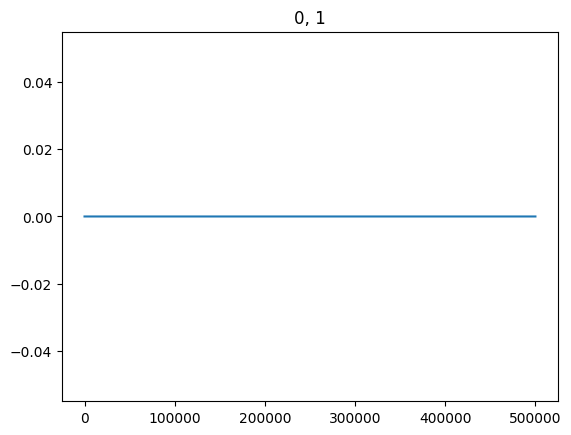

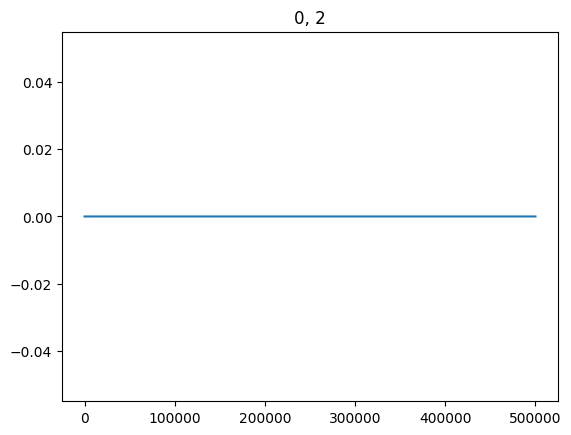

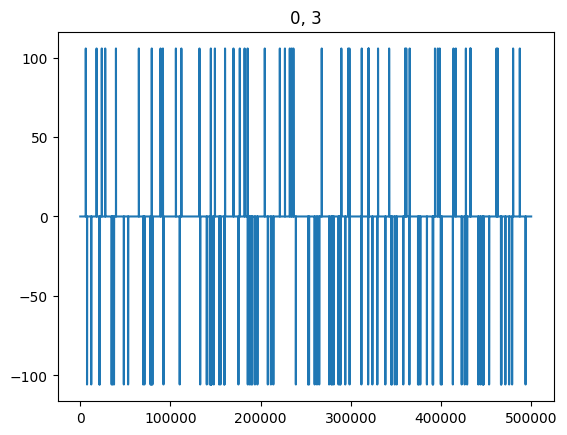

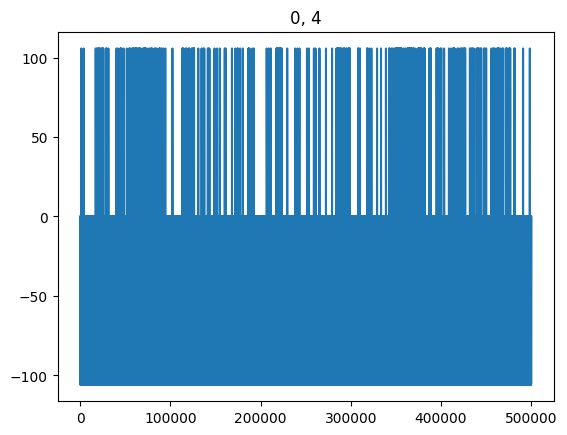

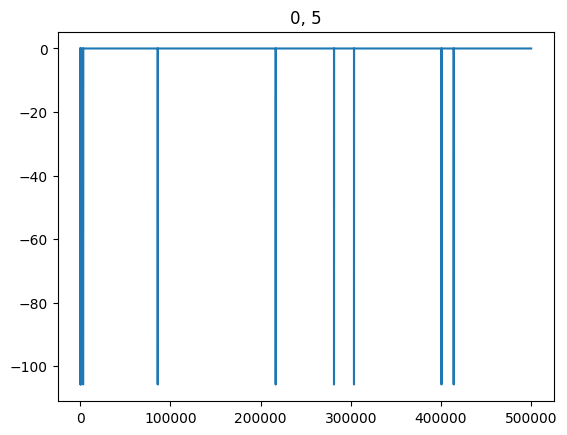

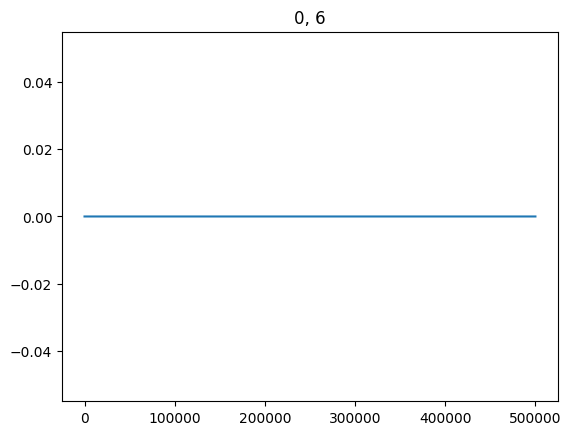

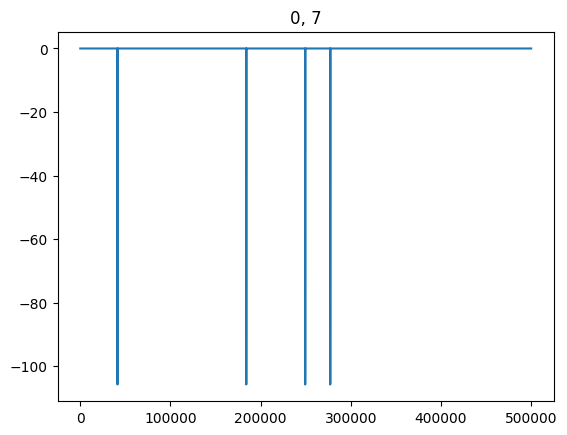

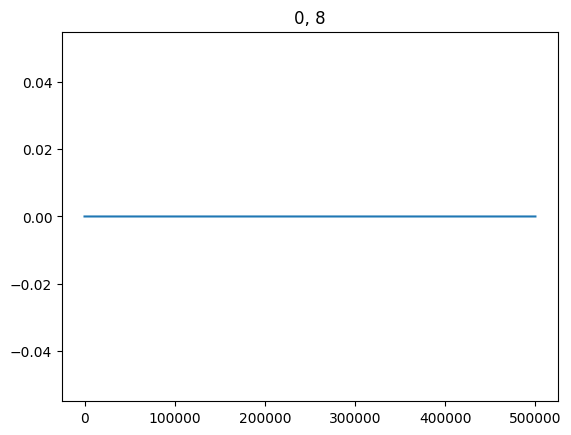

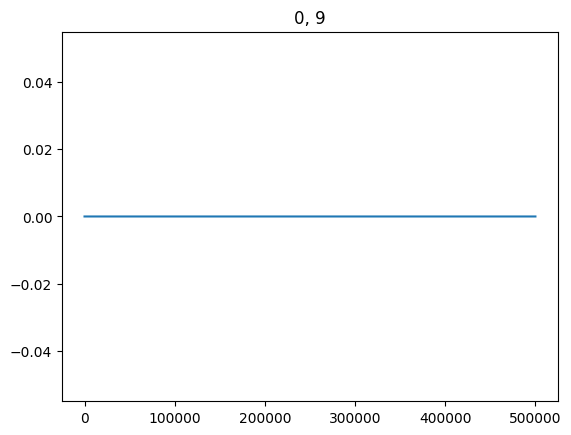

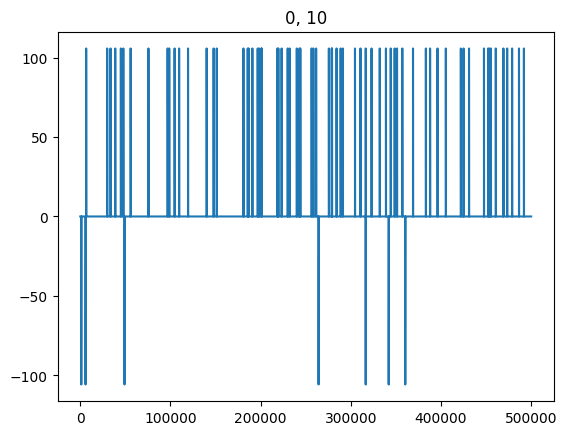

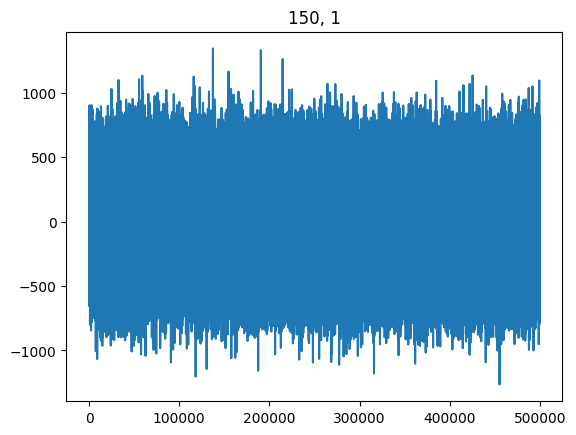

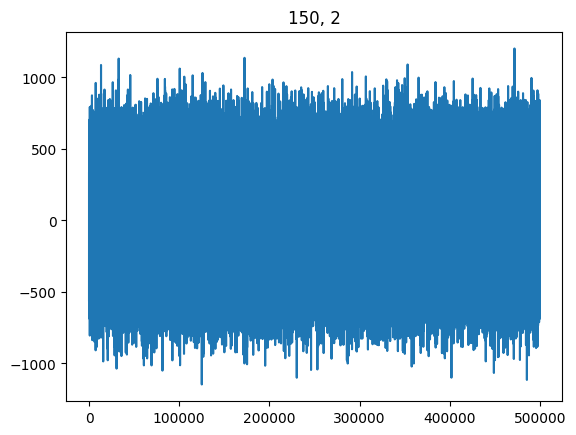

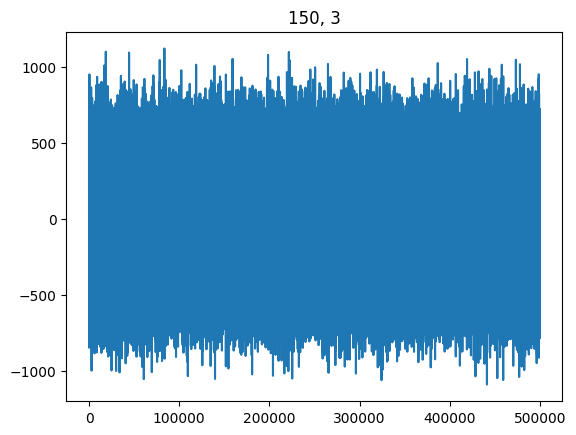

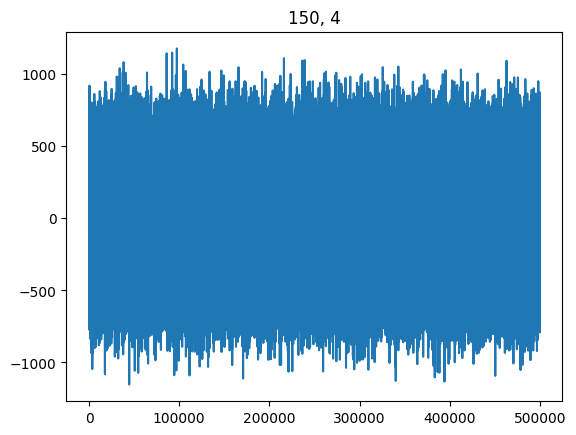

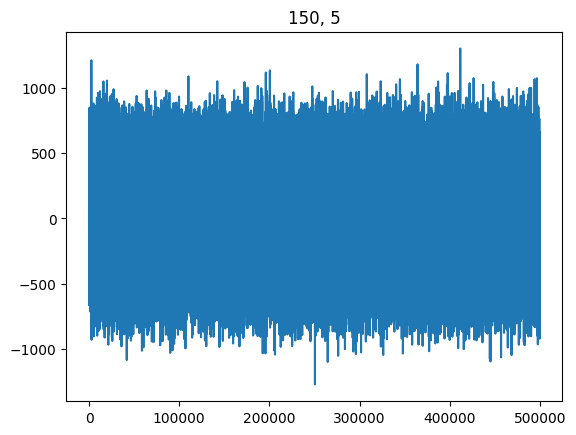

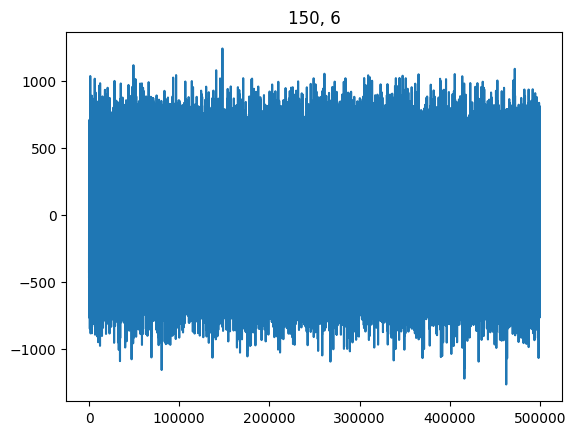

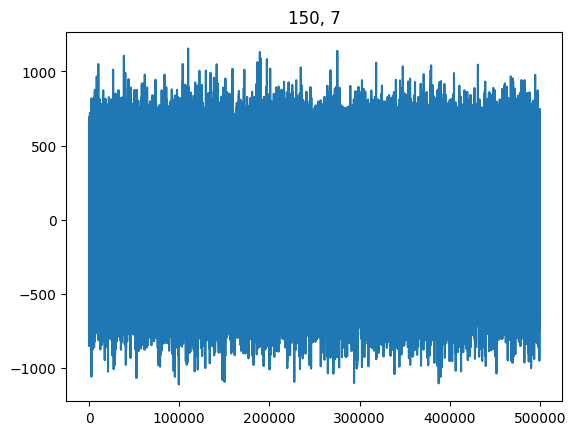

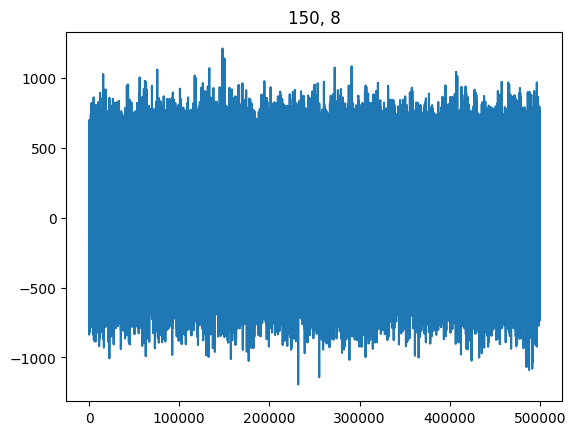

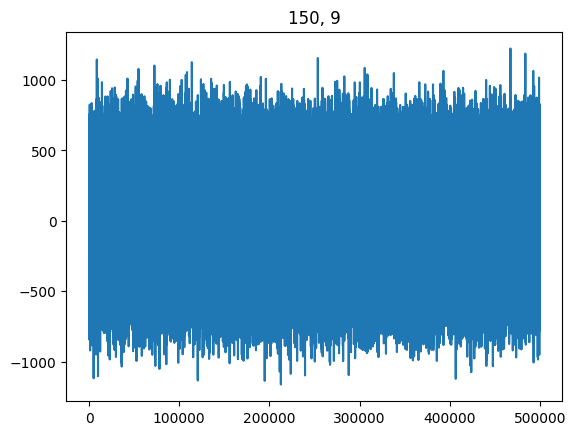

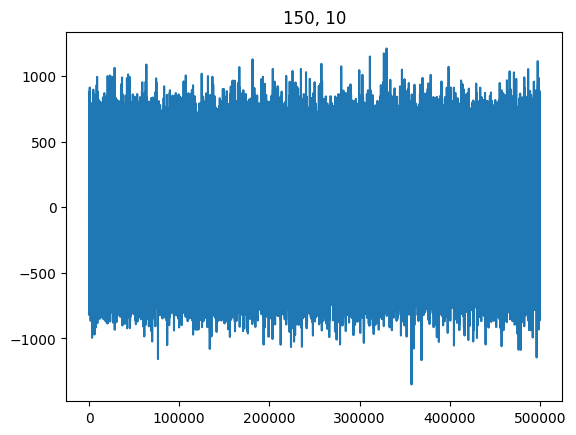

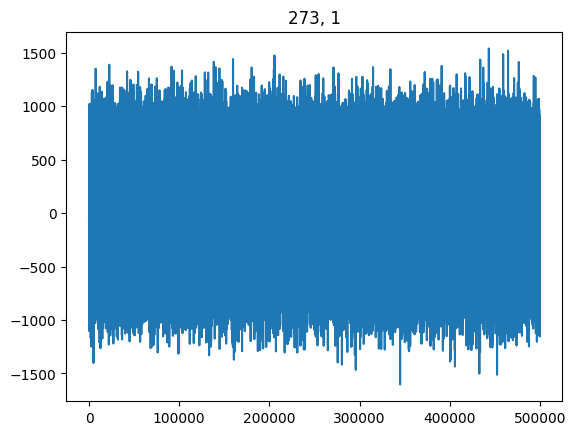

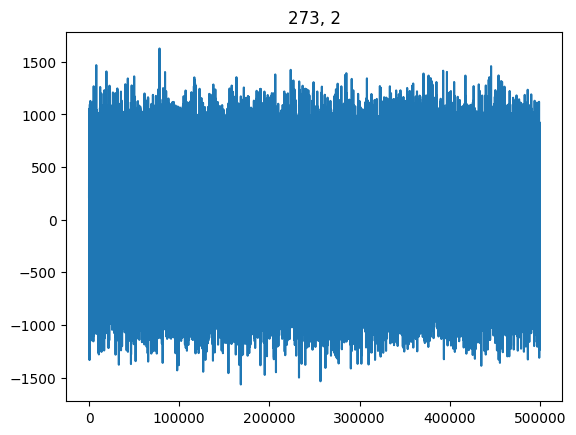

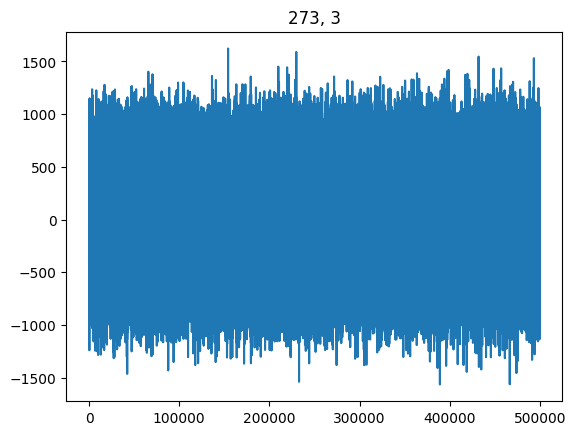

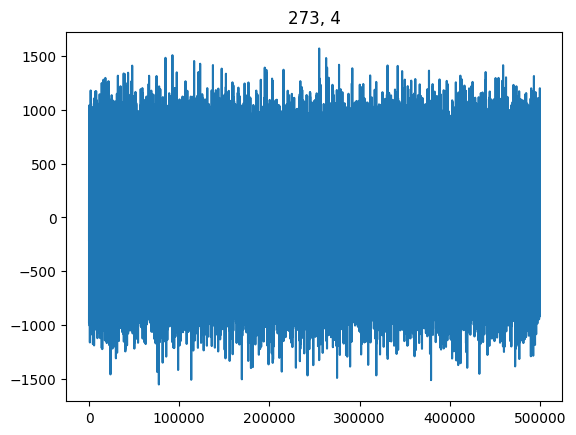

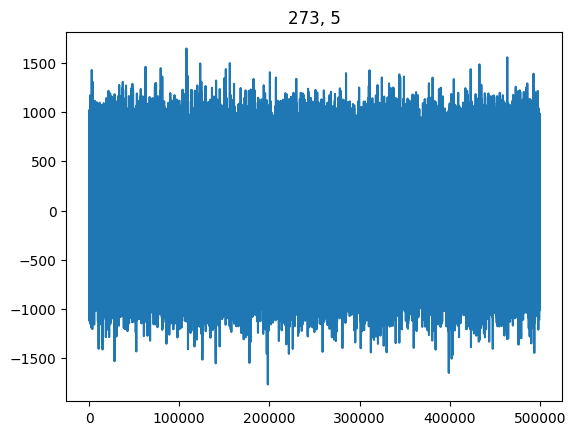

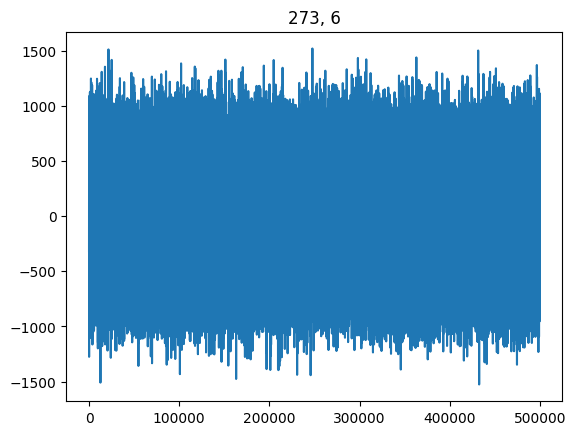

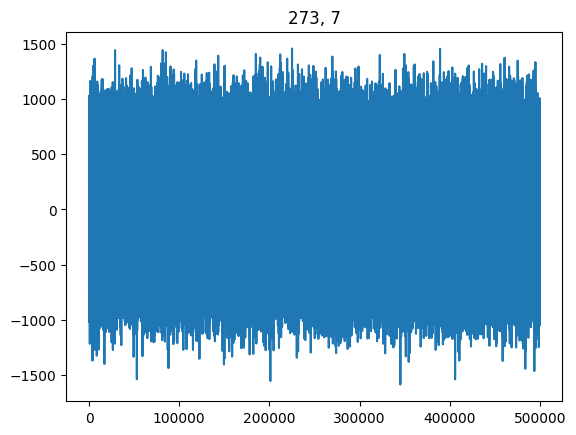

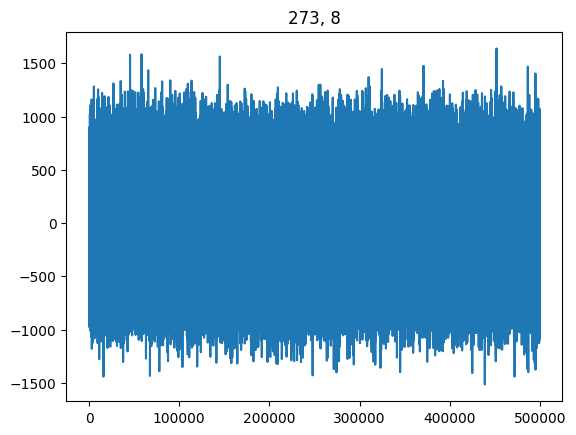

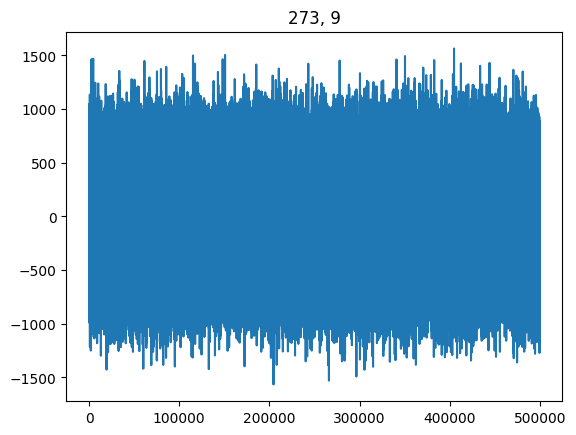

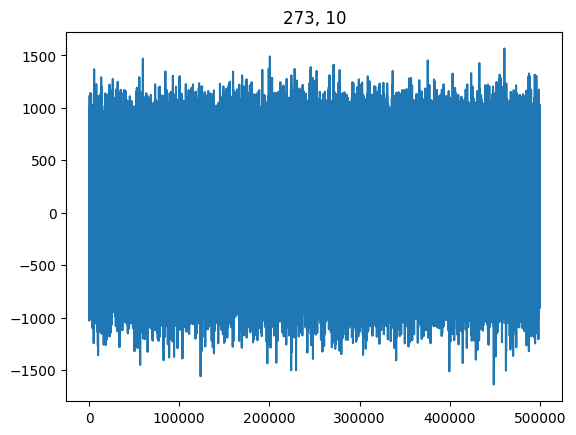

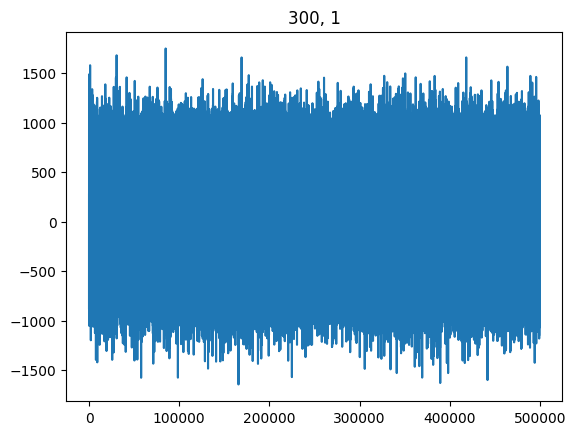

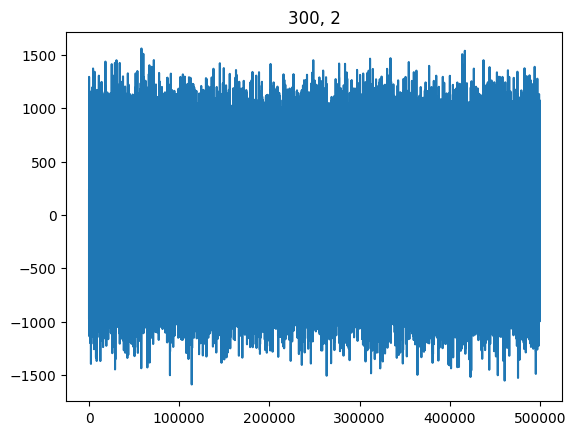

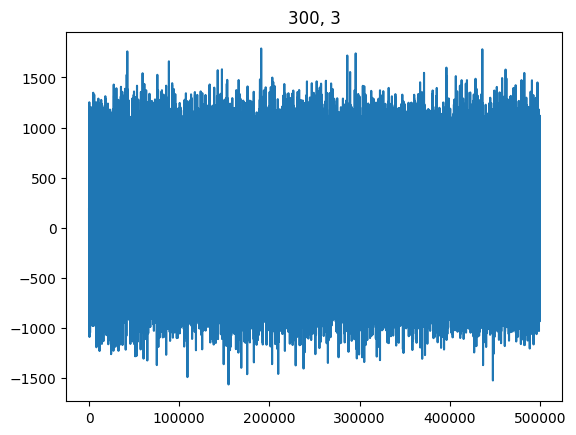

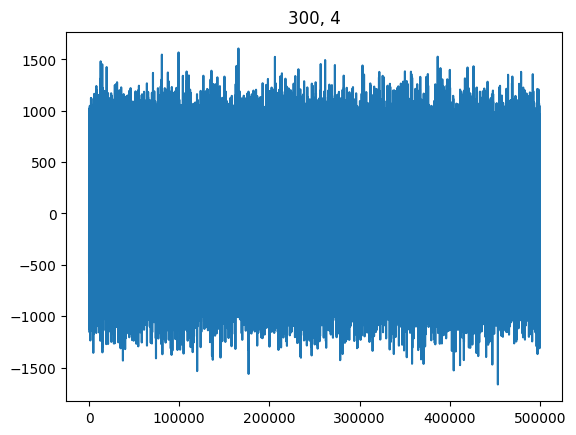

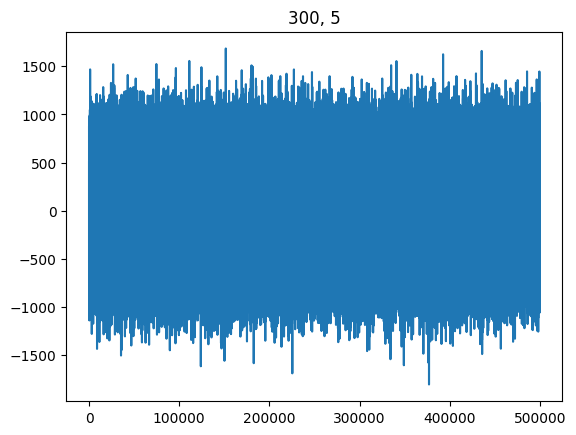

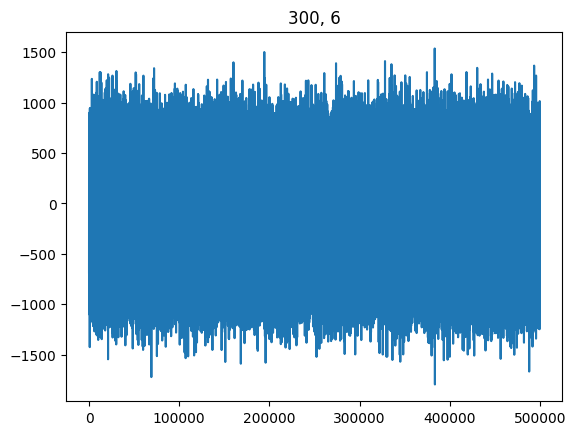

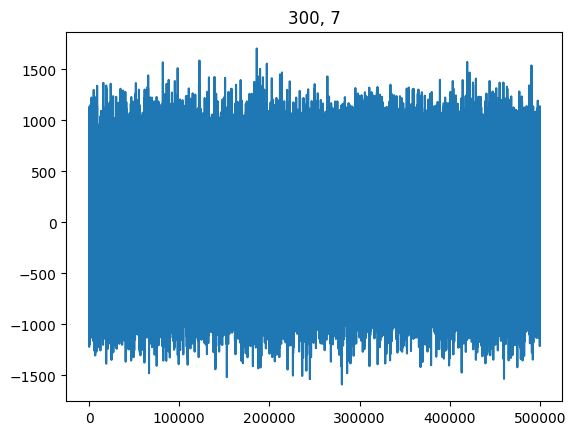

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '300K/8/deployment/trajectory.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
for temperature in temperatures:
    
    for i in range(1, 11, 1):
        _, rod_data= load_data(temperature, i)
        velocity = np.rad2deg(compute_rod_velocity(rod_data))
        velocity = 60 * 60 * velocity / 360
        
        plt.plot(velocity)
        plt.title(f"{temperature}, {i}")
        plt.show()

# Rod Histogram

In [ ]:
speeds = {}

good_models = []
for vision in vision_sizes:

    speed = []
    for i in range(1, 21, 1):
        _, rod_data, _, _ = load_data(vision, i)
        velocity = compute_rod_velocity(rod_data)
        if len(velocity[velocity > 1]) > 5:
            good_models.append(i)
            speed.append(np.mean(abs(velocity)))

    speeds[vision] = Measurement(
        data = np.mean(np.array(speed)),
        uncertainty = np.std(np.array(speed))
    )
    
hist_data = {}
good_models = []
for vision in vision_sizes:

    coordinates = []
    for i in range(1, 21, 1):
        position_data, rod_data, _, _ = load_data(vision, i)
        velocity = compute_rod_velocity(rod_data)
        if len(velocity[velocity > 1]) > 5:
            good_models.append(i)
            coordinates.append(
                transform_coordinates(position_data, rod_data)
            )
                

    hist_data[vision] = Measurement(
        data = coordinates,
        uncertainty = None
    )

In [ ]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2)

colours = ["#044389","#fcff4b","#ffad05","#7cafc4","#5995ed"]
linestyles = ["-", ":", "-.", "--", (5, (10, 3))]

ax = fig.add_subplot(gs[0, :])
img = sns.histplot(
    x=np.concatenate([item for item in hist_data[3].data])[:, :, 0].flatten(),
    y=np.concatenate([item for item in hist_data[3].data])[:, :, 1].flatten(),
    ax=ax,
    bins=1000,
    vmin=None,
    vmax=None,
    cbar=True,
    norm=LogNorm(),
    cmap="Spectral"

)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(-100, 100)
ax.set_ylim(-75, 75)

ax = fig.add_subplot(gs[1, 0])
ax.errorbar(
    vision_sizes, 
    [60 * 60 * np.rad2deg(speeds[item].data / 2) / 360 for item in vision_sizes],
    yerr = [60 * 60 * np.rad2deg(speeds[item].uncertainty / 2) / 360 for item in vision_sizes],
    marker = "o",
    c="k",
    mfc = "none",
    ls = "none",
    capsize=7
)
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel(r"Angular Velocity / rph")

ax = fig.add_subplot(gs[1, 1])
for i, hist in enumerate(hist_data):
    sns.kdeplot(
        x=np.concatenate([item for item in hist_data[hist].data])[:, :, 0].flatten(),
        label=hist,
        ls=linestyles[i],
        c=colours[i],
        ax=ax
        )
    
ax.set_xlabel("Rod Position")
ax.set_xlim(-150, 150)


fig.legend(loc=[0.87, 0.3])

plt.subplots_adjust(wspace=0.3)
plt.savefig("performance-and-strategy.png", dpi=600)
plt.show()